# **Level 3 Task 2: Building Dashboard with Power BI**

**Import Libraries**

In [1]:
import pandas as pd

url = 'https://drive.google.com/uc?id=1HQQa-fPovsiaRwML9V-A6_35x0xdATyz'

df = pd.read_csv(url)

df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


**Data Understanding**

In [2]:
df.shape

(497472, 7)

In [3]:
df.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


**Data Cleaning**

In [5]:
df.isnull().sum()

,0
symbol,0
date,0
open,11
high,8
low,8
close,0
volume,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497464 non-null  float64       
 4   low     497464 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


In [9]:
df = df.dropna()
df = df.drop_duplicates()

In [10]:
df.isnull().sum()

,0
symbol,0
date,0
open,0
high,0
low,0
close,0
volume,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['symbol'].nunique()

505

In [13]:
df['symbol'].value_counts().head(10)

,count
symbol,
YUM,1007
XYL,1007
XRX,1007
XRAY,1007
XOM,1007
XL,1007
XLNX,1007
XEL,1007
XEC,1007


**Feature Engineering**

In [14]:
df['date'].min(), df['date'].max()

(Timestamp('2014-01-02 00:00:00'), Timestamp('2017-12-29 00:00:00'))

In [15]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['quarter'] = df['date'].dt.quarter
df['day'] = df['date'].dt.day

In [16]:
df.head()

,symbol,date,open,high,low,close,volume,year,month,month_name,quarter,day
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2014,1,January,1,2
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,2014,1,January,1,2
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,2014,1,January,1,2
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2014,1,January,1,2
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2014,1,January,1,2


In [17]:
df['daily_change'] = df['close'] - df['open']

In [18]:
df['price_range'] = df['high'] - df['low']

In [19]:
df['return_pct'] = ((df['close'] - df['open']) / df['open']) * 100

In [20]:
df.head()

,symbol,date,open,high,low,close,volume,year,month,month_name,quarter,day,daily_change,price_range,return_pct
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2014,1,January,1,2,0.2900,0.7600,1.156761
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,2014,1,January,1,2,-0.3643,0.7155,-0.458916
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,2014,1,January,1,2,-0.6200,2.5900,-0.561798
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2014,1,January,1,2,-0.1400,0.8100,-0.268611
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2014,1,January,1,2,-0.2200,0.7500,-0.313793


Save Cleaned Dataset

In [21]:
df.to_csv('stock_dashboard_cleaned.csv', index=False)

In [22]:
from google.colab import files
files.download('stock_dashboard_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

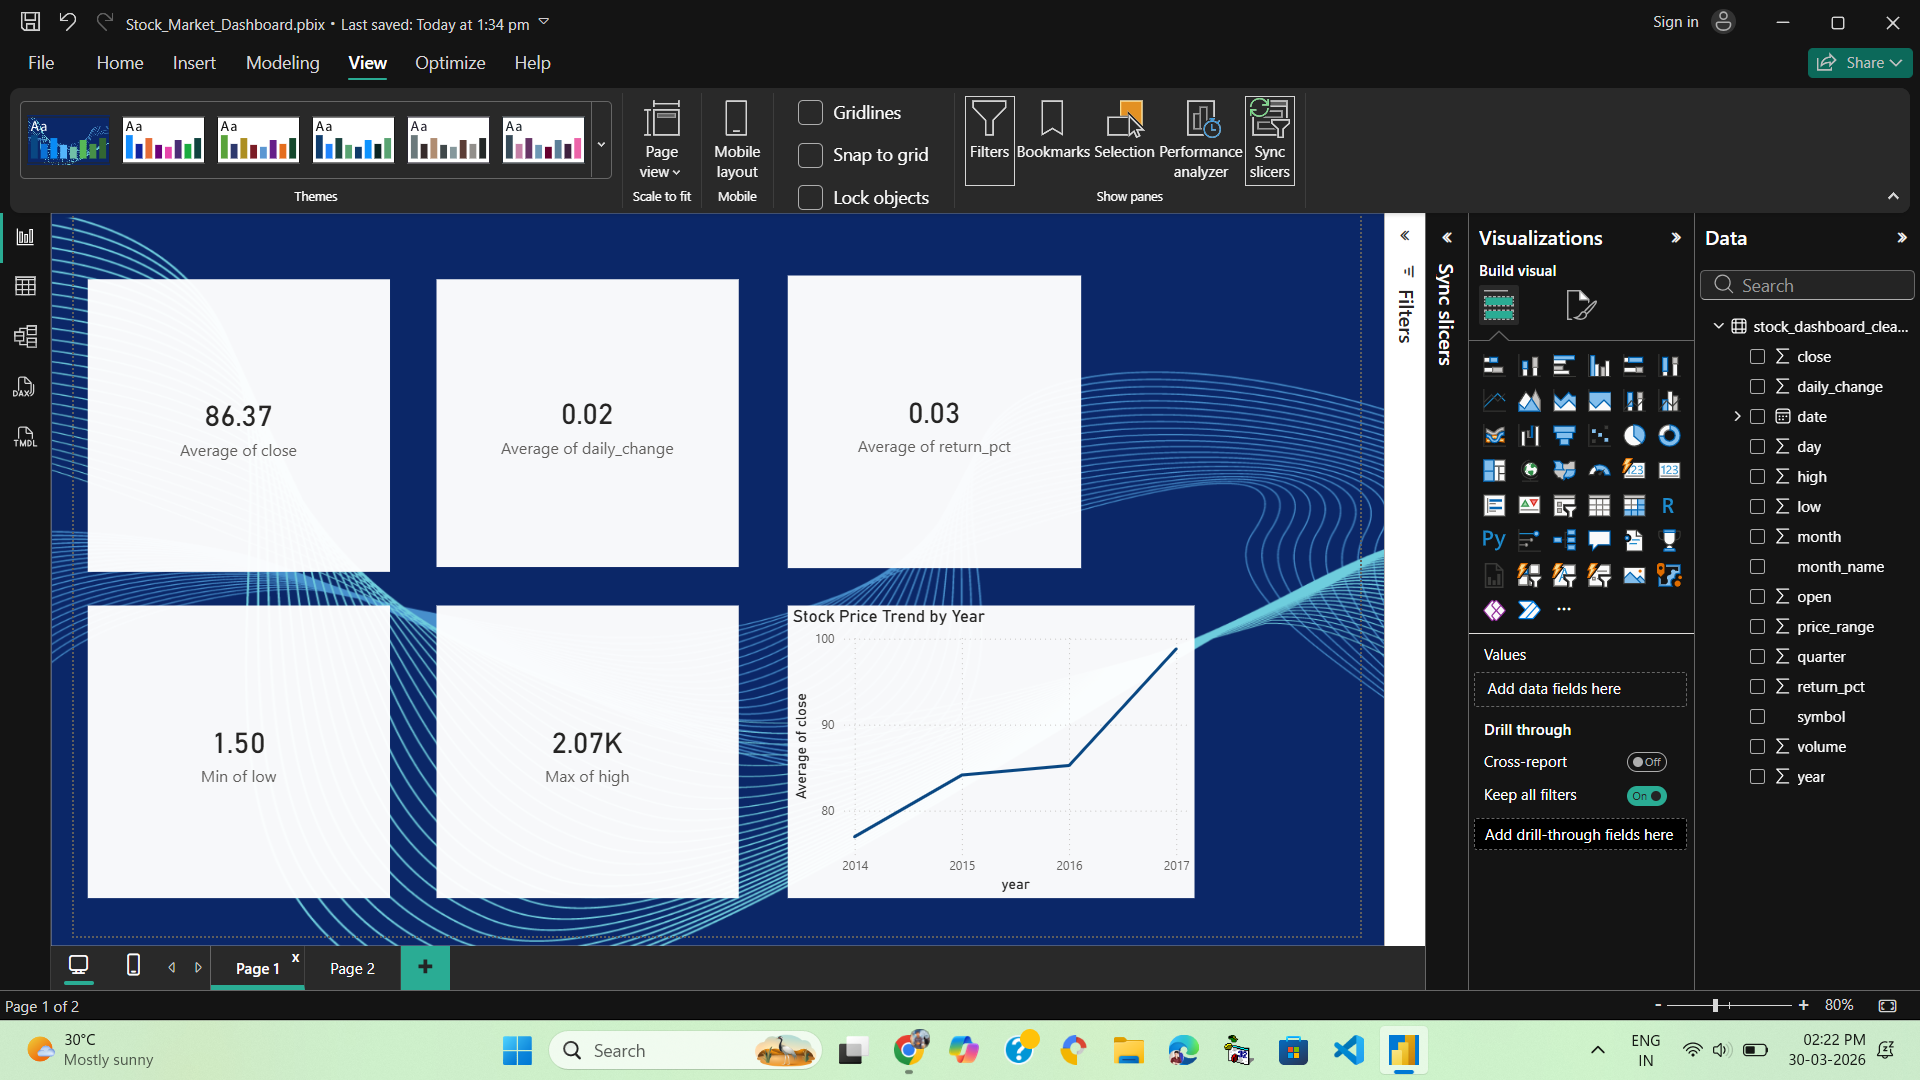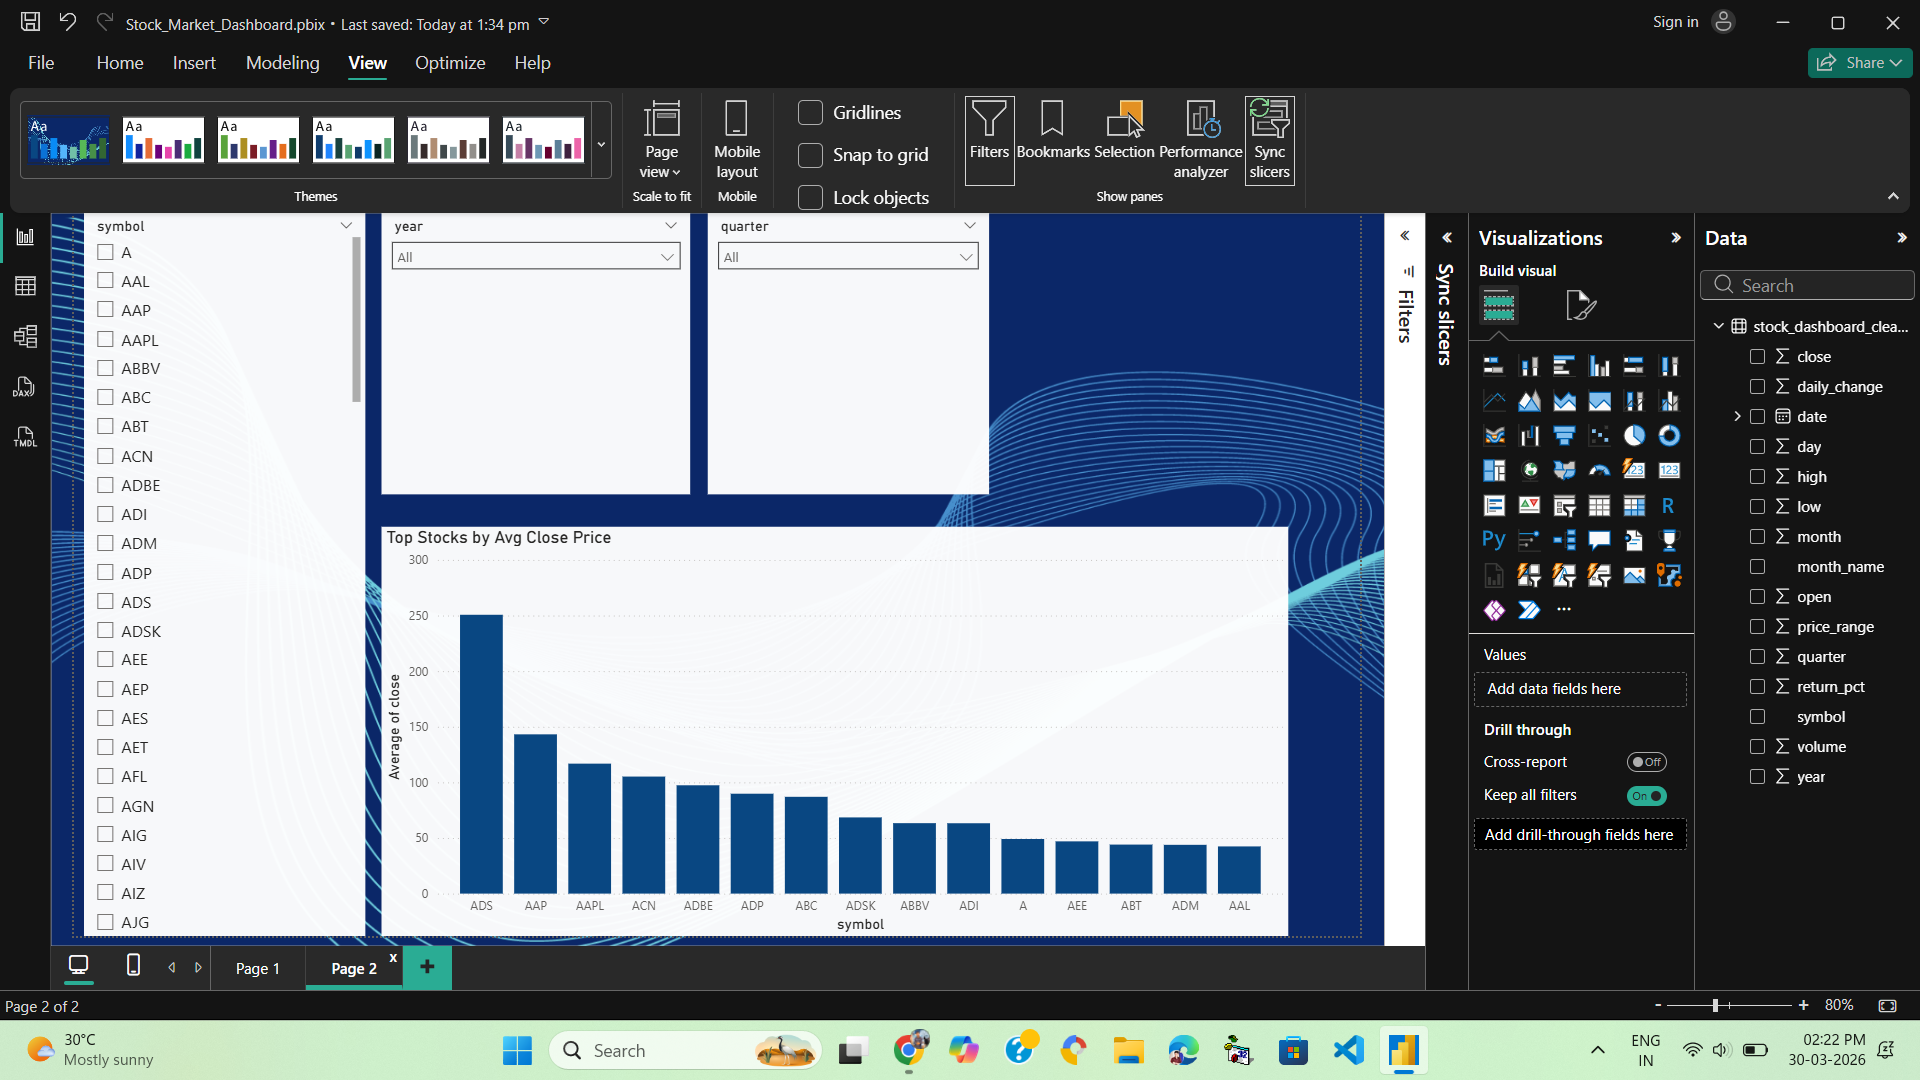

# **Conclusion **

**In this project, a Power BI dashboard was built to analyze stock market data interactively. The dashboard highlights price trends, trading volume, and volatility using charts, KPI cards, and slicers. This project showcases how dashboards can transform raw financial data into meaningful business insights.**